In [1]:
#importing
import csv
import numpy as np
import matplotlib.pyplot as plt
import copy
import math
import keras
import pandas as pd
import xgboost as xgb
import os
from scipy.stats import norm

from keras.models import Sequential
from keras.layers import Dense, BatchNormalization, Dropout
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_auc_score

In [2]:
XGBoost_distances_all_data = []

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15604
X shape: (15604, 16)
y shape: (15604, 2)
X coordinate range: -29.9999 to 29.9952
Y coordinate range: -29.9876 to 29.9973
Average XGBoost Delta X (mm): -4.992908947525453e-05
Median XGBoost Delta X (mm): -0.00030399829864488637
Average XGBoost Delta Y (mm): -0.00025998383542926237
Median XGBoost Delta Y (mm): -0.0018428533813484257


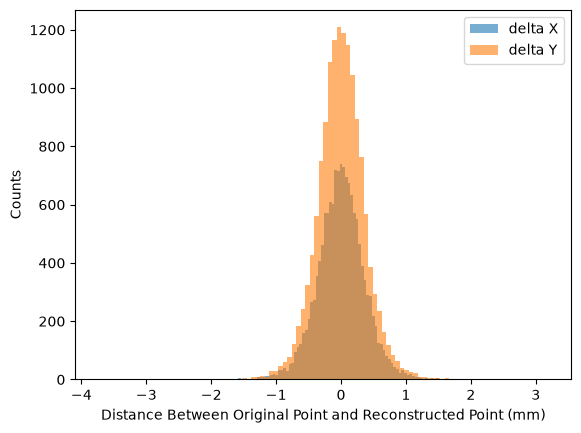

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15523
X shape: (15523, 16)
y shape: (15523, 2)
X coordinate range: -29.9979 to 29.9977
Y coordinate range: -29.9955 to 29.9965
Average XGBoost Delta X (mm): 0.0009228509607932156
Median XGBoost Delta X (mm): 0.0006393356323236773
Average XGBoost Delta Y (mm): 0.0020554461057013117
Median XGBoost Delta Y (mm): 0.0006374625549318592


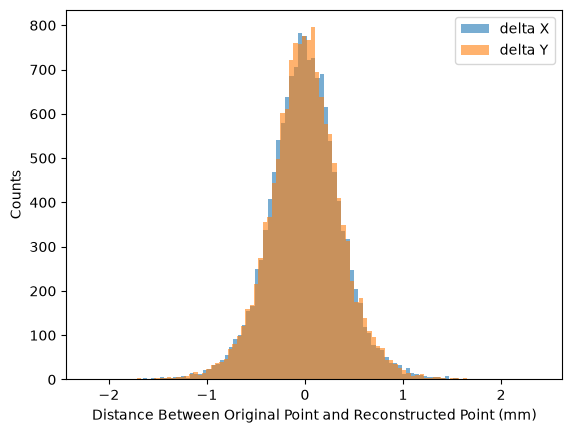

Original number of events: 100000
Original X shape: (100000, 16)
Original y shape: (100000, 2)

After 5 mm cut:
Number of events: 77868
X shape: (77868, 16)
y shape: (77868, 2)
X coordinate range: -29.9996 to 29.9994
Y coordinate range: -29.9984 to 29.998
Average XGBoost Delta X (mm): 0.00027038204612290286
Median XGBoost Delta X (mm): 0.0017001431274412003
Average XGBoost Delta Y (mm): -0.0003921793227393017
Median XGBoost Delta Y (mm): -0.0005877233891486734


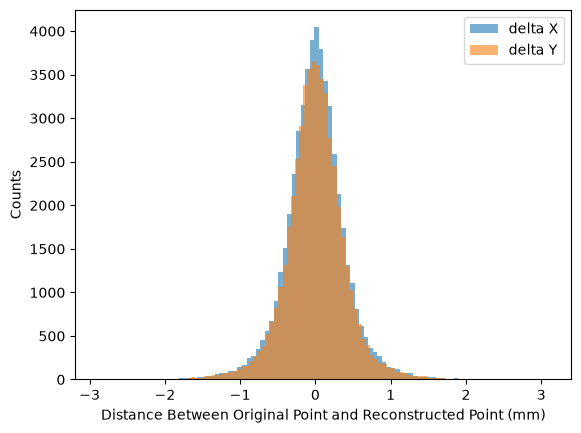

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15583
X shape: (15583, 16)
y shape: (15583, 2)
X coordinate range: -29.996 to 29.9907
Y coordinate range: -29.999 to 29.9982
Average XGBoost Delta X (mm): -0.00012692977797950955
Median XGBoost Delta X (mm): 0.0011411335010528042
Average XGBoost Delta Y (mm): -0.0020532718281571546
Median XGBoost Delta Y (mm): -0.0009492134094241308


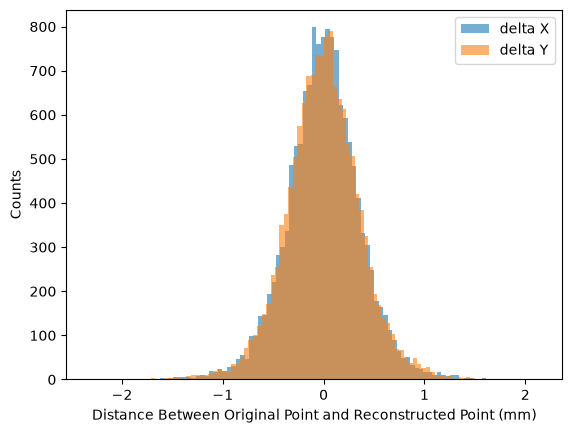

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15589
X shape: (15589, 16)
y shape: (15589, 2)
X coordinate range: -29.9975 to 29.9936
Y coordinate range: -29.9925 to 29.9962
Average XGBoost Delta X (mm): -0.00042043045889777315
Median XGBoost Delta X (mm): 0.0012627193450926374
Average XGBoost Delta Y (mm): -0.00029679134582212313
Median XGBoost Delta Y (mm): -0.0011958885192878826


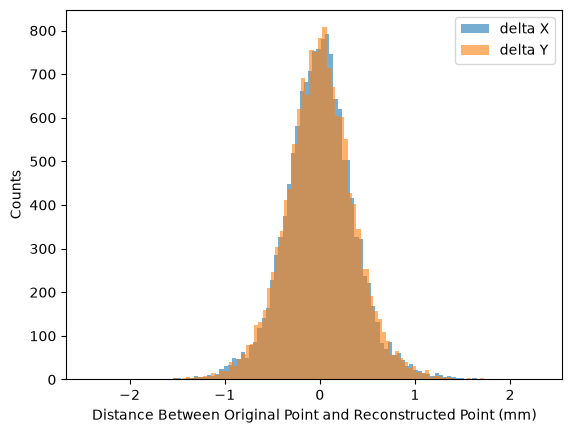

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15585
X shape: (15585, 16)
y shape: (15585, 2)
X coordinate range: -29.998 to 29.9903
Y coordinate range: -29.9953 to 29.9944
Average XGBoost Delta X (mm): 0.0011419923486149348
Median XGBoost Delta X (mm): -0.0005321693420416438
Average XGBoost Delta Y (mm): -0.0004108249356388292
Median XGBoost Delta Y (mm): -0.000684880664825244


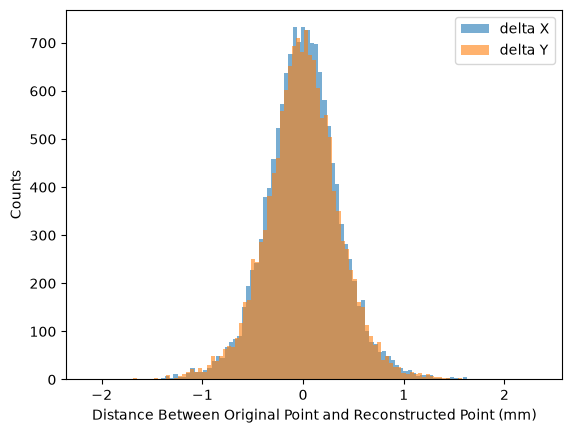

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15576
X shape: (15576, 16)
y shape: (15576, 2)
X coordinate range: -29.9987 to 29.9866
Y coordinate range: -29.9986 to 29.9998
Average XGBoost Delta X (mm): 0.001133179275682824
Median XGBoost Delta X (mm): 0.0015823693847661219
Average XGBoost Delta Y (mm): 0.0020137235096382654
Median XGBoost Delta Y (mm): 0.003325367507934558


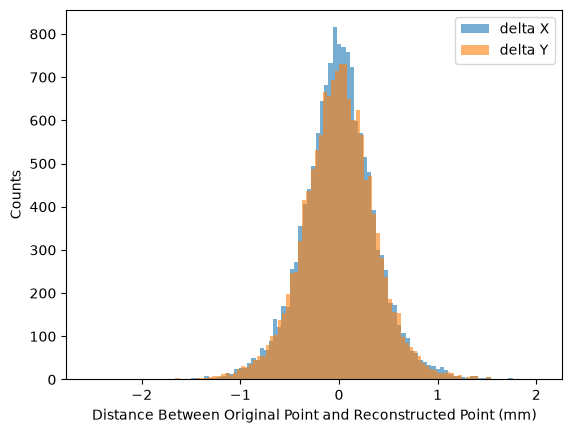

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15526
X shape: (15526, 16)
y shape: (15526, 2)
X coordinate range: -29.9978 to 29.9991
Y coordinate range: -29.9989 to 29.9993
Average XGBoost Delta X (mm): -0.0009164351869514468
Median XGBoost Delta X (mm): -0.002962820816039267
Average XGBoost Delta Y (mm): 0.0012516025614808933
Median XGBoost Delta Y (mm): -0.0007571998977667395


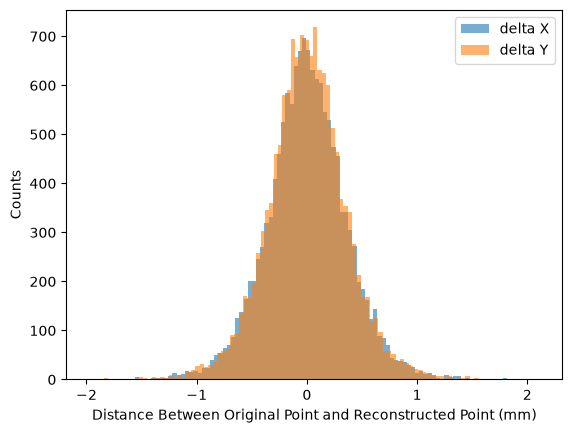

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15462
X shape: (15462, 16)
y shape: (15462, 2)
X coordinate range: -29.9998 to 29.9987
Y coordinate range: -29.9998 to 29.99
Average XGBoost Delta X (mm): 0.00015760827444049127
Median XGBoost Delta X (mm): -0.002466859741211108
Average XGBoost Delta Y (mm): 3.0802399551919776e-05
Median XGBoost Delta Y (mm): 0.0033044978332522797


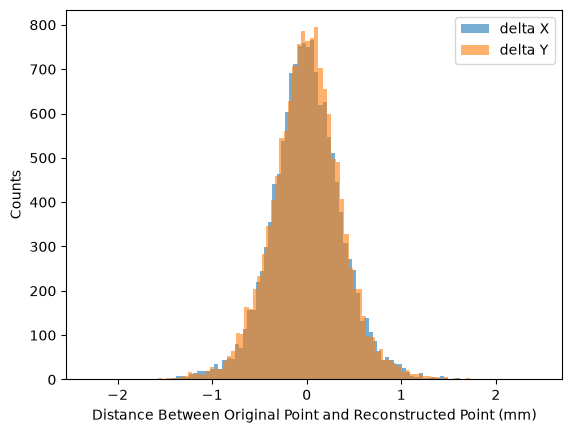

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15537
X shape: (15537, 16)
y shape: (15537, 2)
X coordinate range: -29.9938 to 29.9919
Y coordinate range: -29.9953 to 29.9924
Average XGBoost Delta X (mm): -0.0011005546200295536
Median XGBoost Delta X (mm): -0.000977940368651526
Average XGBoost Delta Y (mm): -9.516759297814026e-05
Median XGBoost Delta Y (mm): -0.0015238692474369491


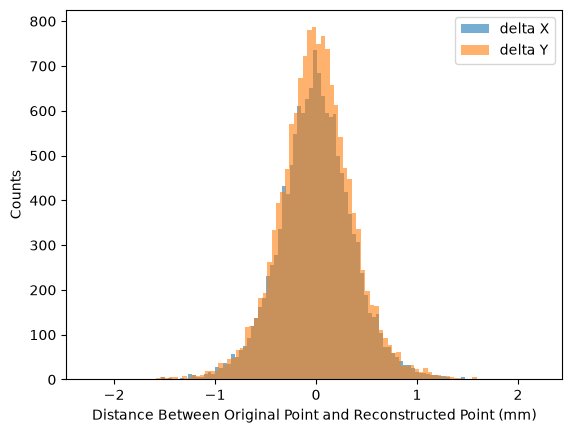

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15558
X shape: (15558, 16)
y shape: (15558, 2)
X coordinate range: -29.9973 to 29.9958
Y coordinate range: -29.9919 to 29.999
Average XGBoost Delta X (mm): -0.0018719810411843834
Median XGBoost Delta X (mm): 0.0011308178901676702
Average XGBoost Delta Y (mm): 0.00033168432885121563
Median XGBoost Delta Y (mm): -0.0009628645706174065


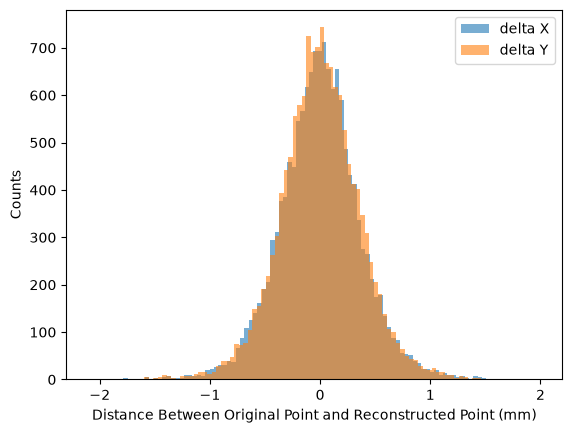

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15569
X shape: (15569, 16)
y shape: (15569, 2)
X coordinate range: -29.9997 to 29.9996
Y coordinate range: -29.9936 to 29.9994
Average XGBoost Delta X (mm): -0.0001610864126175016
Median XGBoost Delta X (mm): 0.0031801496887210196
Average XGBoost Delta Y (mm): -0.00033098200298570685
Median XGBoost Delta Y (mm): -0.0036664001464828296


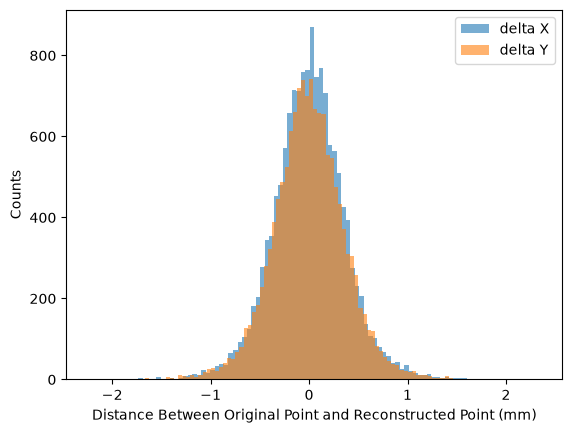

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15524
X shape: (15524, 16)
y shape: (15524, 2)
X coordinate range: -29.993 to 29.9988
Y coordinate range: -29.9949 to 29.9742
Average XGBoost Delta X (mm): -0.00019754514469960677
Median XGBoost Delta X (mm): 0.0005956507301339937
Average XGBoost Delta Y (mm): 0.0010538537539956832
Median XGBoost Delta Y (mm): -0.0008906711196897451


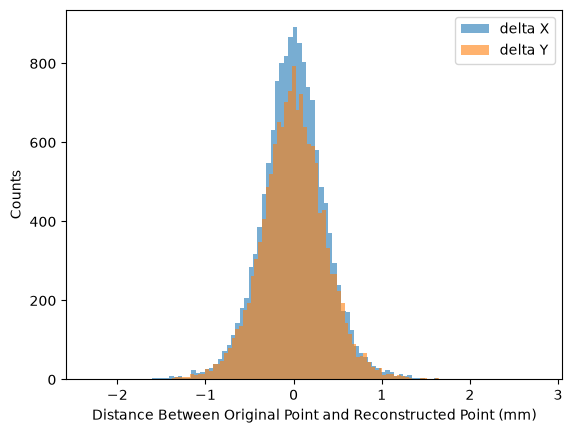

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15619
X shape: (15619, 16)
y shape: (15619, 2)
X coordinate range: -29.9976 to 29.9998
Y coordinate range: -29.9946 to 29.9996
Average XGBoost Delta X (mm): -0.0005539116449727226
Median XGBoost Delta X (mm): -0.0010963623046862467
Average XGBoost Delta Y (mm): 0.0009362776623982829
Median XGBoost Delta Y (mm): -0.002871554565430756


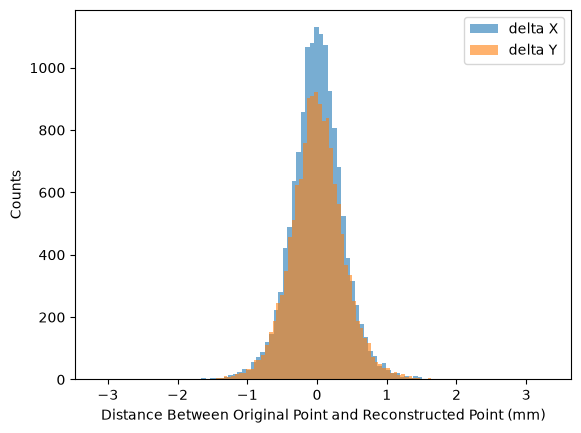

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15569
X shape: (15569, 16)
y shape: (15569, 2)
X coordinate range: -29.9997 to 29.9992
Y coordinate range: -29.9991 to 29.9923
Average XGBoost Delta X (mm): 0.0013792961393048315
Median XGBoost Delta X (mm): 0.0003788919830322278
Average XGBoost Delta Y (mm): 6.083585816447885e-05
Median XGBoost Delta Y (mm): 0.00041178398132313276


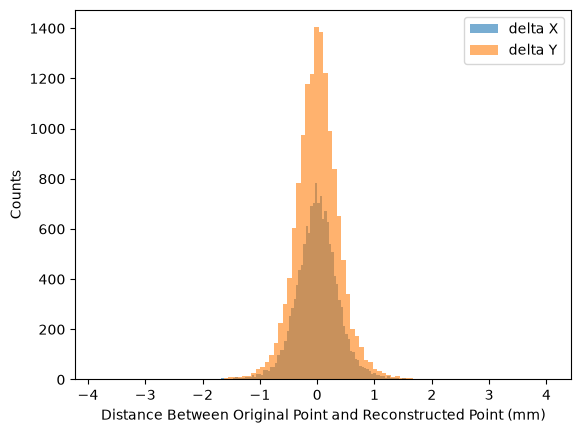

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15662
X shape: (15662, 16)
y shape: (15662, 2)
X coordinate range: -29.9938 to 29.9952
Y coordinate range: -29.9998 to 29.9959
Average XGBoost Delta X (mm): 0.0010947902824956128
Median XGBoost Delta X (mm): -0.0003492541503906203
Average XGBoost Delta Y (mm): -0.0017085968121427174
Median XGBoost Delta Y (mm): 0.0024922630310051375


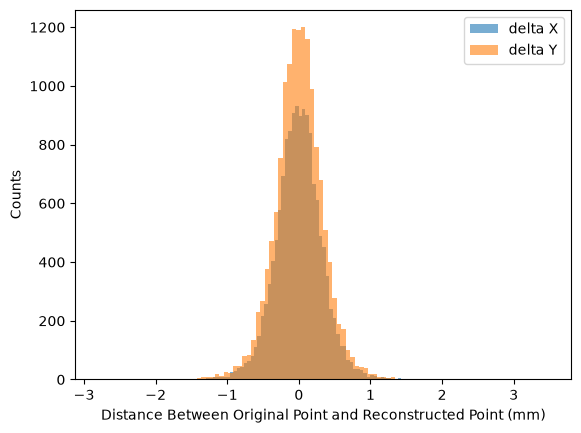

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15552
X shape: (15552, 16)
y shape: (15552, 2)
X coordinate range: -29.9987 to 29.9961
Y coordinate range: -29.9995 to 29.9994
Average XGBoost Delta X (mm): -0.00028856190946756436
Median XGBoost Delta X (mm): 0.0009853757286069275
Average XGBoost Delta Y (mm): -0.0036306829060879712
Median XGBoost Delta Y (mm): -0.0034564964294421666


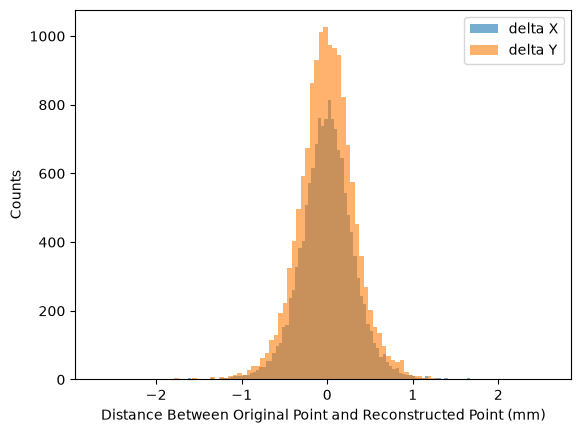

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15462
X shape: (15462, 16)
y shape: (15462, 2)
X coordinate range: -29.9965 to 29.9965
Y coordinate range: -29.9998 to 29.9966
Average XGBoost Delta X (mm): -0.0008262456711616798
Median XGBoost Delta X (mm): 0.00034130859374989985
Average XGBoost Delta Y (mm): -0.0011458219885329098
Median XGBoost Delta Y (mm): -0.000788589477539875


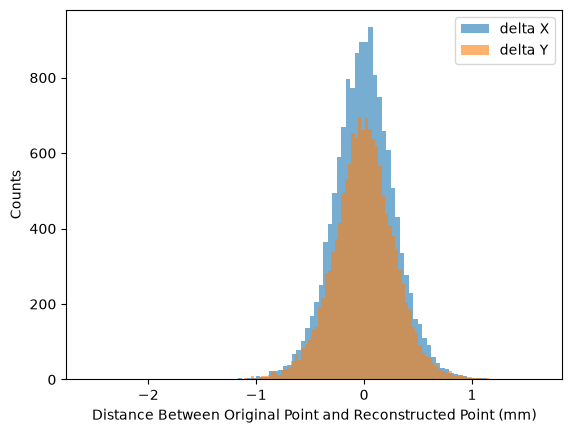

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15539
X shape: (15539, 16)
y shape: (15539, 2)
X coordinate range: -29.9946 to 29.9949
Y coordinate range: -29.999 to 29.996
Average XGBoost Delta X (mm): -0.0005696911386686617
Median XGBoost Delta X (mm): 0.0013666763305671629
Average XGBoost Delta Y (mm): 0.00096457317436839
Median XGBoost Delta Y (mm): -0.00036435516357432446


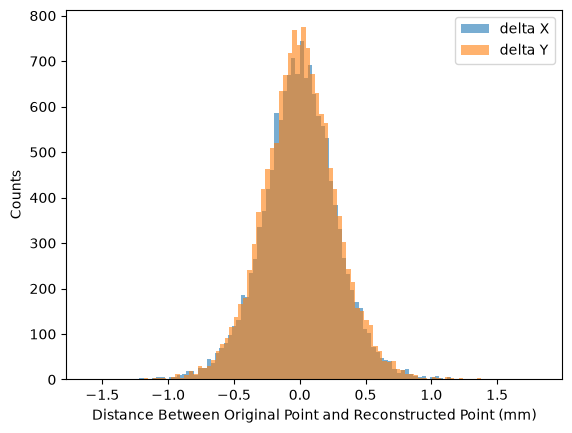

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15533
X shape: (15533, 16)
y shape: (15533, 2)
X coordinate range: -29.9981 to 29.9913
Y coordinate range: -29.9984 to 29.9972
Average XGBoost Delta X (mm): -0.0005786615638466599
Median XGBoost Delta X (mm): 0.001500572456550597
Average XGBoost Delta Y (mm): -0.0007600542183910598
Median XGBoost Delta Y (mm): 1.1678314209897026e-05


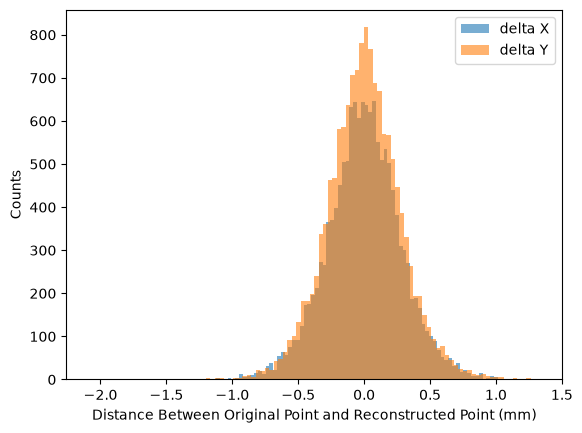

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15565
X shape: (15565, 16)
y shape: (15565, 2)
X coordinate range: -29.9982 to 29.9966
Y coordinate range: -29.9918 to 29.9949
Average XGBoost Delta X (mm): -0.002549137058517991
Median XGBoost Delta X (mm): -0.0010268972682951915
Average XGBoost Delta Y (mm): -0.0008095532336486833
Median XGBoost Delta Y (mm): 0.0004671916580195985


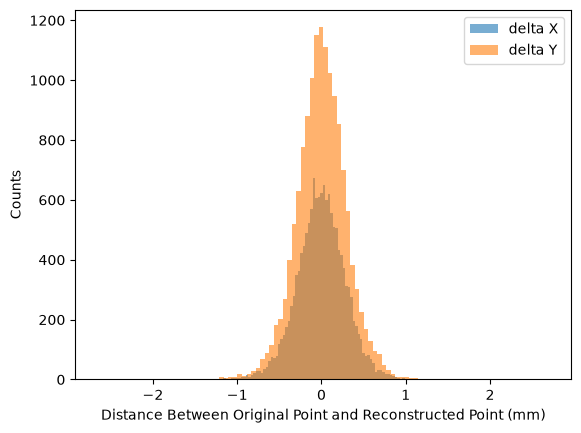

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15693
X shape: (15693, 16)
y shape: (15693, 2)
X coordinate range: -29.9911 to 29.9967
Y coordinate range: -29.996 to 29.9996
Average XGBoost Delta X (mm): 0.002436821424778081
Median XGBoost Delta X (mm): 0.0011296234130874433
Average XGBoost Delta Y (mm): -0.0018571547165033406
Median XGBoost Delta Y (mm): -5.606376647957281e-05


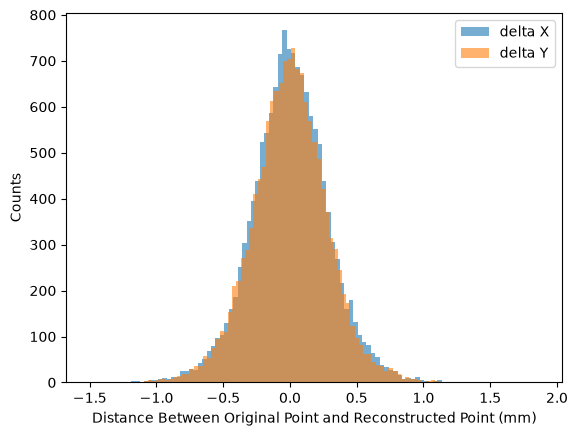

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15601
X shape: (15601, 16)
y shape: (15601, 2)
X coordinate range: -29.9955 to 29.9981
Y coordinate range: -29.9929 to 29.9996
Average XGBoost Delta X (mm): -0.0001249087571218525
Median XGBoost Delta X (mm): -0.002017024230957183
Average XGBoost Delta Y (mm): 0.0008422870546140027
Median XGBoost Delta Y (mm): 0.0017920999145509624


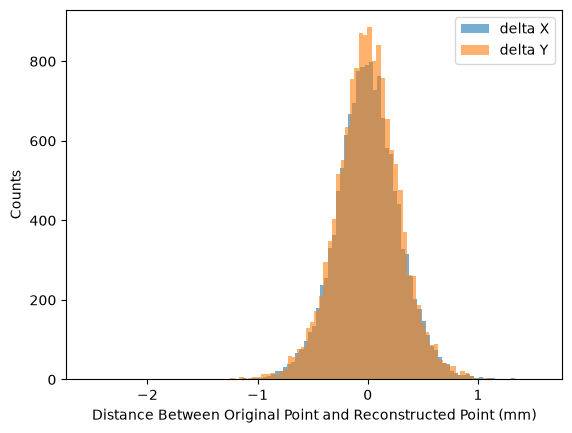

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15616
X shape: (15616, 16)
y shape: (15616, 2)
X coordinate range: -29.9998 to 29.9999
Y coordinate range: -29.9997 to 29.998
Average XGBoost Delta X (mm): -0.0009732377457744127
Median XGBoost Delta X (mm): 0.00016347808837976346
Average XGBoost Delta Y (mm): 0.0006823024084989324
Median XGBoost Delta Y (mm): 9.689315795959053e-05


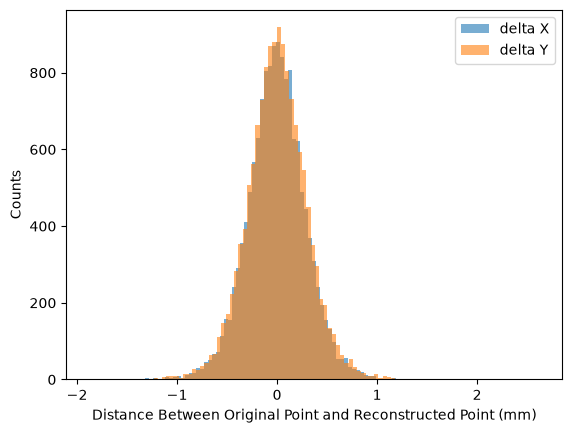

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15563
X shape: (15563, 16)
y shape: (15563, 2)
X coordinate range: -29.9992 to 29.9973
Y coordinate range: -29.998 to 29.9948
Average XGBoost Delta X (mm): -0.0005289049796954231
Median XGBoost Delta X (mm): 0.0006683380126965167
Average XGBoost Delta Y (mm): 0.00015225957284016706
Median XGBoost Delta Y (mm): 0.0007549201965338197


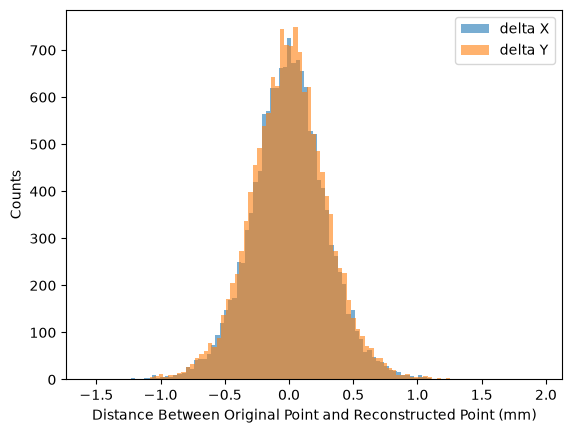

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15574
X shape: (15574, 16)
y shape: (15574, 2)
X coordinate range: -29.9902 to 29.9977
Y coordinate range: -29.9941 to 29.9935
Average XGBoost Delta X (mm): -0.00041922558638663913
Median XGBoost Delta X (mm): -0.0007754798126216053
Average XGBoost Delta Y (mm): 0.0002932095242565628
Median XGBoost Delta Y (mm): 0.0036798477935792084


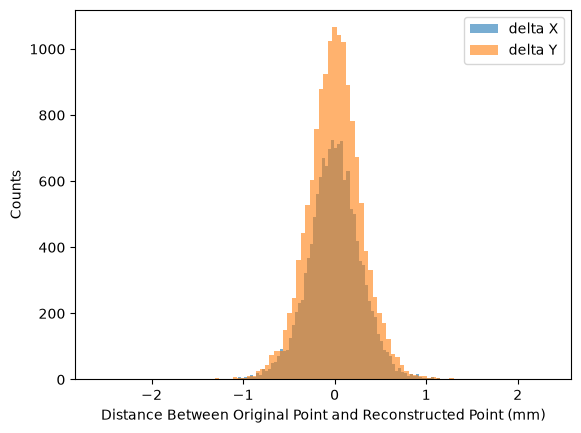

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15602
X shape: (15602, 16)
y shape: (15602, 2)
X coordinate range: -29.995 to 29.9997
Y coordinate range: -29.9939 to 29.9949
Average XGBoost Delta X (mm): -0.0006443127056841156
Median XGBoost Delta X (mm): -7.95743942261281e-05
Average XGBoost Delta Y (mm): -0.00014846635949235942
Median XGBoost Delta Y (mm): 0.0006108505249038413


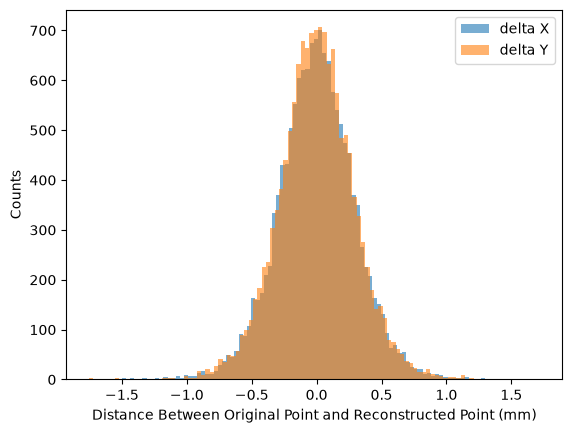

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15621
X shape: (15621, 16)
y shape: (15621, 2)
X coordinate range: -29.9923 to 29.9991
Y coordinate range: -29.9991 to 29.9965
Average XGBoost Delta X (mm): 0.00038778404176777095
Median XGBoost Delta X (mm): -0.004207492828369122
Average XGBoost Delta Y (mm): 0.0004920336032617037
Median XGBoost Delta Y (mm): -0.0025699172973624226


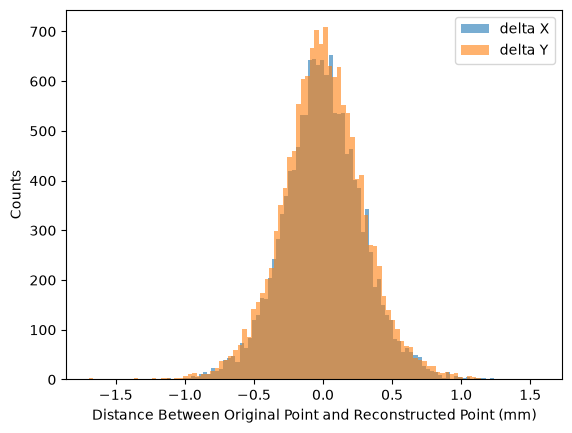

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15527
X shape: (15527, 16)
y shape: (15527, 2)
X coordinate range: -29.9994 to 29.9997
Y coordinate range: -29.9917 to 29.9902
Average XGBoost Delta X (mm): 0.0008013818027626493
Median XGBoost Delta X (mm): 0.0005335449218744539
Average XGBoost Delta Y (mm): 0.0006324566971229985
Median XGBoost Delta Y (mm): 0.00212846221923897


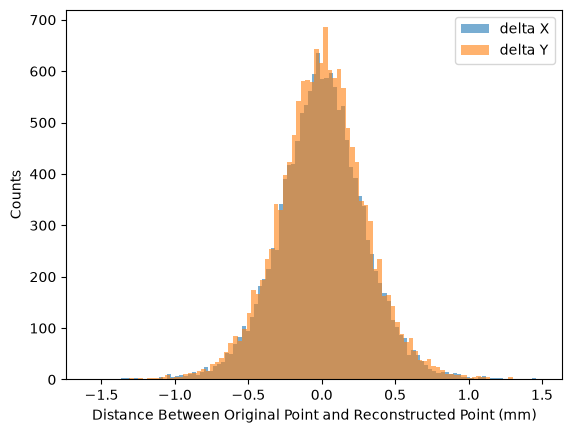

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15597
X shape: (15597, 16)
y shape: (15597, 2)
X coordinate range: -29.9956 to 29.9995
Y coordinate range: -29.9995 to 29.9844
Average XGBoost Delta X (mm): -0.00031637280341919764
Median XGBoost Delta X (mm): -0.0016855941772476596
Average XGBoost Delta Y (mm): -0.0003040808328951868
Median XGBoost Delta Y (mm): -0.0006249496459954486


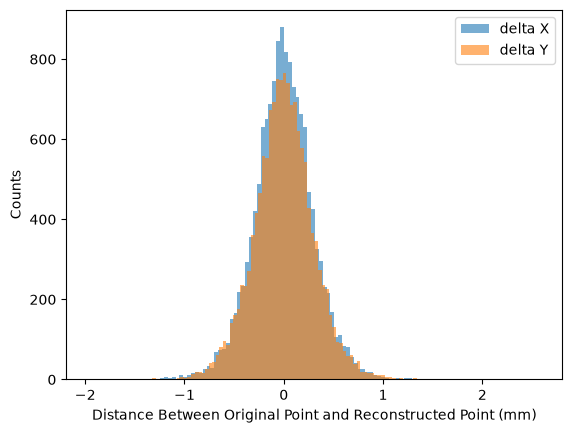

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15671
X shape: (15671, 16)
y shape: (15671, 2)
X coordinate range: -29.9966 to 29.9952
Y coordinate range: -30.0 to 29.9983
Average XGBoost Delta X (mm): 0.0007033879191430291
Median XGBoost Delta X (mm): 0.002006449508666826
Average XGBoost Delta Y (mm): 0.0010414245586736288
Median XGBoost Delta Y (mm): -0.00042629957580625835


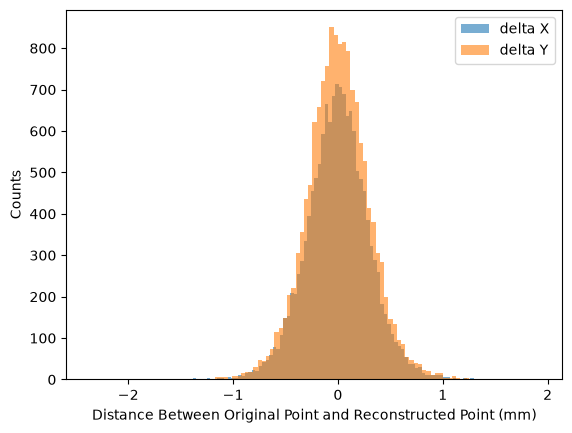

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15567
X shape: (15567, 16)
y shape: (15567, 2)
X coordinate range: -29.9998 to 29.989
Y coordinate range: -29.9984 to 29.9995
Average XGBoost Delta X (mm): 0.0005409772697023597
Median XGBoost Delta X (mm): 0.0016350305557251638
Average XGBoost Delta Y (mm): -0.00018024473437347631
Median XGBoost Delta Y (mm): -0.002867621154784849


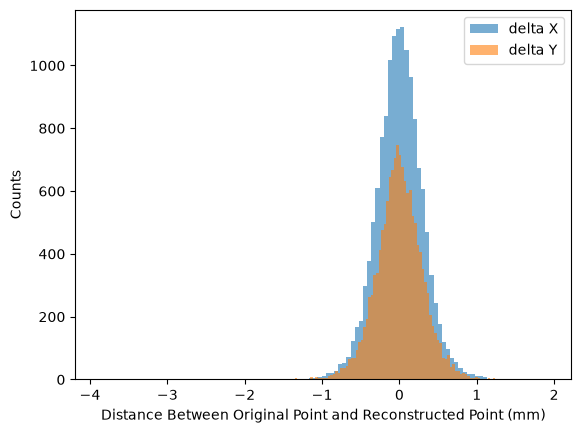

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15585
X shape: (15585, 16)
y shape: (15585, 2)
X coordinate range: -29.9949 to 29.9937
Y coordinate range: -29.999 to 29.9874
Average XGBoost Delta X (mm): 0.0005279899385542488
Median XGBoost Delta X (mm): 3.46675109863543e-05
Average XGBoost Delta Y (mm): -0.0007286993805191092
Median XGBoost Delta Y (mm): 0.0007506354522700334


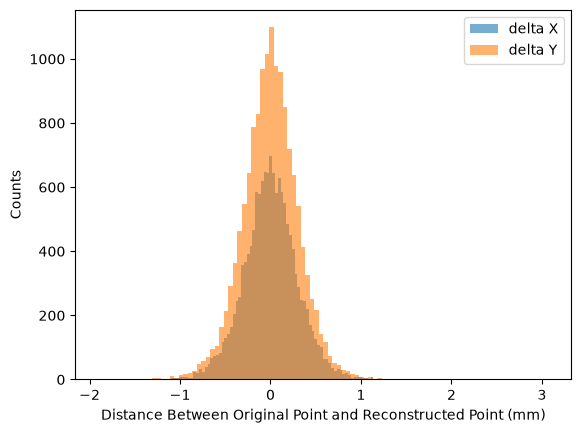

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15633
X shape: (15633, 16)
y shape: (15633, 2)
X coordinate range: -29.9988 to 29.9966
Y coordinate range: -29.997 to 29.9963
Average XGBoost Delta X (mm): -0.0005668801973610092
Median XGBoost Delta X (mm): -4.379119872996635e-05
Average XGBoost Delta Y (mm): 0.00012831665282460878
Median XGBoost Delta Y (mm): -0.0018018959045408072


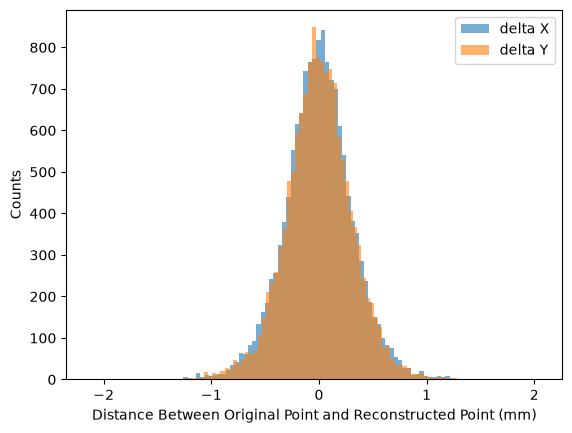

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15513
X shape: (15513, 16)
y shape: (15513, 2)
X coordinate range: -29.9993 to 29.9949
Y coordinate range: -29.9942 to 29.9982
Average XGBoost Delta X (mm): -0.001563227683612014
Median XGBoost Delta X (mm): -0.0017300721359253353
Average XGBoost Delta Y (mm): -0.000912168256037446
Median XGBoost Delta Y (mm): 0.0009873748016346988


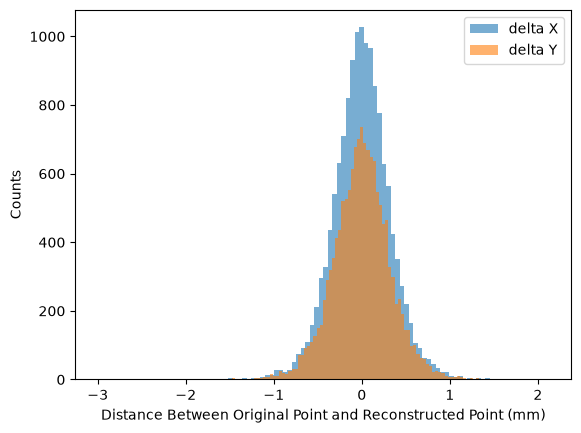

In [3]:
numbers = [3.05, 4.05, 5.05, 6.05, 7.05, 8.05, 9.05, 10.05, 11.05, 12.05, 13.05, 14.05, 14.3, 14.55, 14.8, 15.05, 15.3, 15.55, 15.8, 16.05, 16.3, 16.55, 16.8, 17.05, 17.3, 17.55, 17.8, 18.05, 18.3, 18.55, 18.8, 19.05, 20.05, 25.05, 40.05]

# new region: x = -30 mm to +30 mm; y = -30 mm to +30 mm
region_size = 30  # half-width in mm
grid_half_size = round(region_size * 5)
grid_size = 2 * grid_half_size + 1

for q in numbers:

    file_path = os.path.join('/Users/judyz/Desktop/PET-4x4/build',f'{q}mm',f'{q}mm.csv')
    csvreader = csv.reader(open(file_path))

    original_X = []
    original_y = []

    line_count = 0
    for row in csvreader:
        if line_count >= 1:

            original_X.append([int(i) for i in row[1:17]])
            original_y.append([float(row[17]),float(row[18])])
        line_count += 1

    X = np.array(original_X)
    y = np.array(original_y)

    print("Original number of events:", len(X))
    print("Original X shape:", X.shape)
    print("Original y shape:", y.shape)

    mask = (
        (y[:, 0] >= -region_size) &
        (y[:, 0] <= region_size) &
        (y[:, 1] >= -region_size) &
        (y[:, 1] <= region_size)
    )

    X = X[mask]
    y = y[mask]

    print("\nAfter 5 mm cut:")
    print("Number of events:", len(X))
    print("X shape:", X.shape)
    print("y shape:", y.shape)

    print("X coordinate range:",np.min(y[:, 0]),"to",np.max(y[:, 0]))
    print("Y coordinate range:",np.min(y[:, 1]),"to",np.max(y[:, 1]))

    #XGBoost
    # 60 mm x 60 mm region; 301 x 301 grid

    XGBoost_distances = np.zeros(
        (grid_size, grid_size, 2)
    )

    scaler = StandardScaler()

    for k in range(10):

        X_XGBoost = scaler.fit_transform(X)
        X_train, X_val, y_train, y_val = train_test_split(X_XGBoost, y, test_size=0.3)
            
        model = xgb.XGBRegressor()
        model.fit(X_train,y_train)

        yhat = model.predict(X_XGBoost)
        for i in range(len(X)):

            x_index = grid_half_size + round(y[i][0] * 5)
            y_index = grid_half_size - round(y[i][1] * 5)

            if (0 <= x_index < grid_size and 0 <= y_index < grid_size):
                XGBoost_distances[x_index,y_index,0] = k/(k+1)*XGBoost_distances[x_index,y_index,0] + 1/(k+1)*(yhat[i][0] - y[i][0])
                XGBoost_distances[x_index,y_index,1] = k/(k+1)*XGBoost_distances[x_index,y_index,1] + 1/(k+1)*(yhat[i][1] - y[i][1])
    delta_x = XGBoost_distances[:, :, 0]
    delta_y = XGBoost_distances[:, :, 1]

    delta_x = delta_x[delta_x != 0]
    delta_y = delta_y[delta_y != 0]

    print("Average XGBoost Delta X (mm):",np.mean(delta_x))
    print("Median XGBoost Delta X (mm):",np.median(delta_x))
    print("Average XGBoost Delta Y (mm):",np.mean(delta_y))
    print("Median XGBoost Delta Y (mm):",np.median(delta_y))

    plt.hist(delta_x,bins=100,alpha=0.6,label='delta X')
    plt.hist(delta_y,bins=100,alpha=0.6,label='delta Y')
    plt.xlabel('Distance Between Original Point and Reconstructed Point (mm)')
    plt.ylabel('Counts')
    plt.legend(loc='upper right')
    plt.show()

    XGBoost_distances_all_data.append(XGBoost_distances)

35


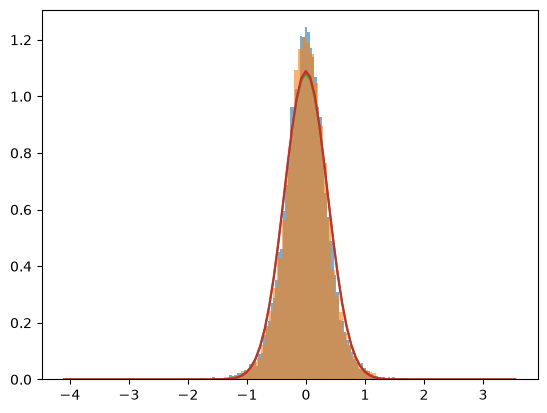

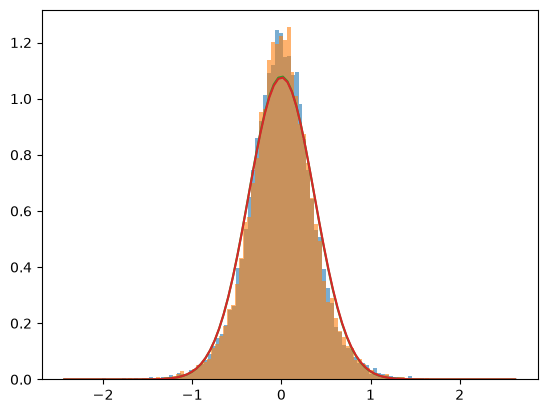

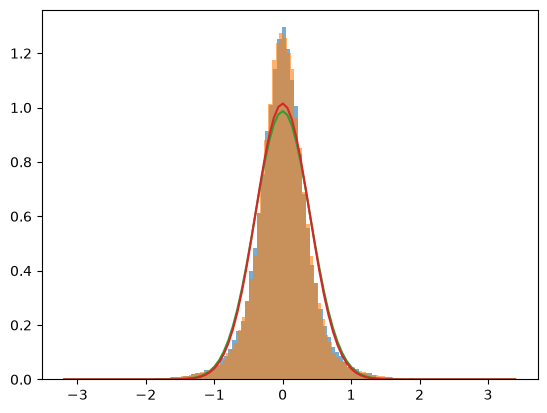

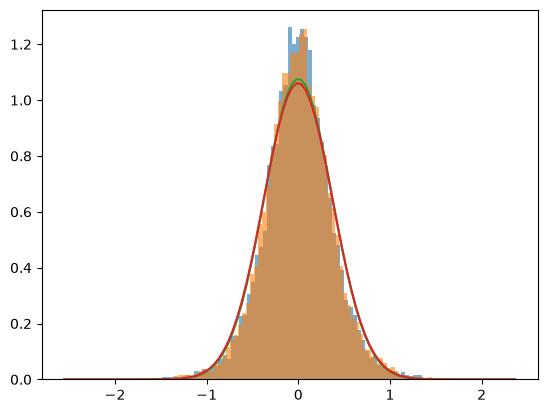

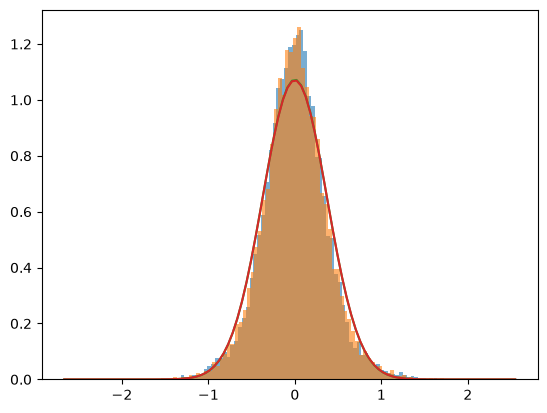

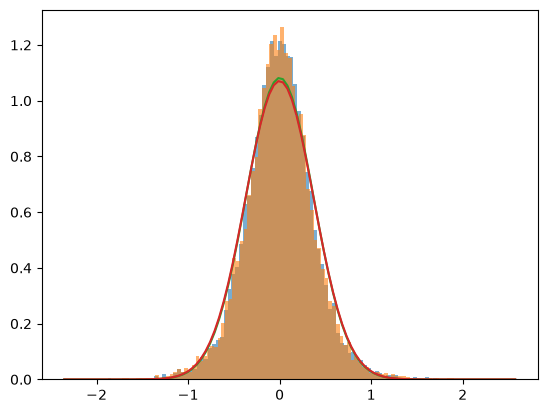

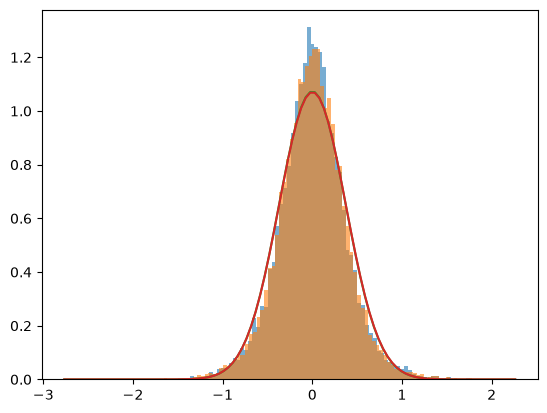

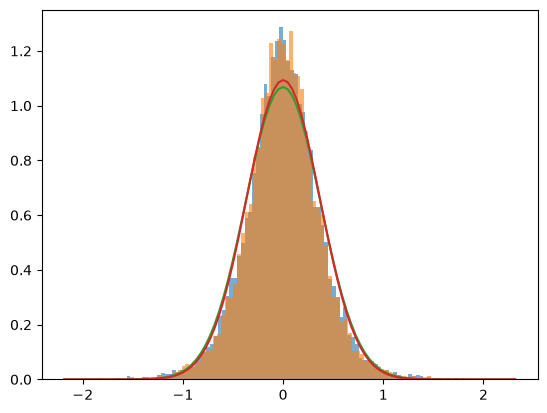

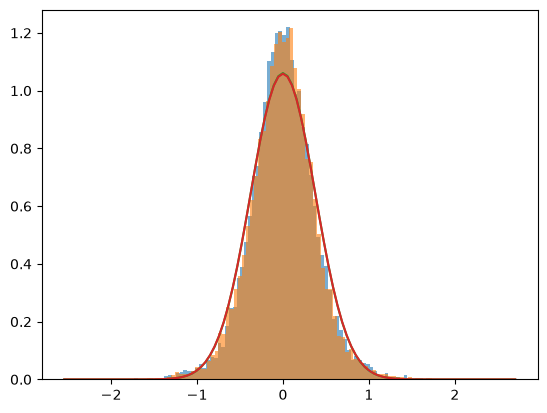

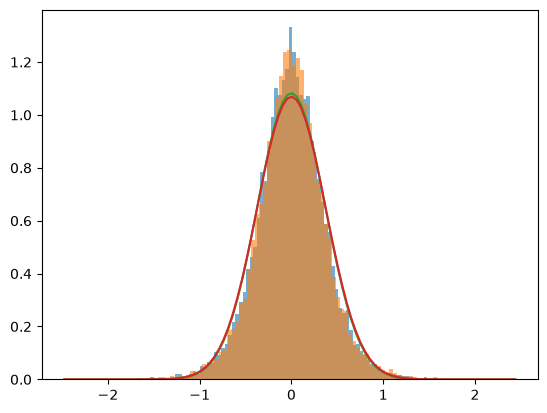

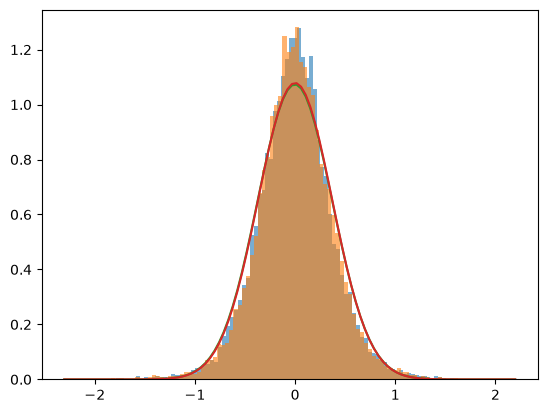

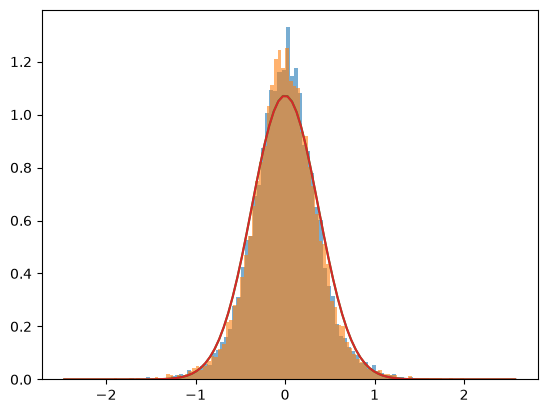

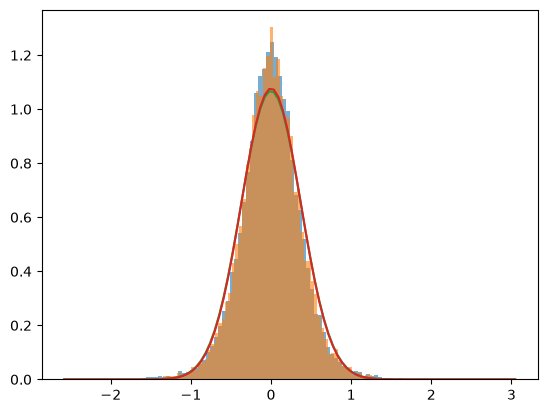

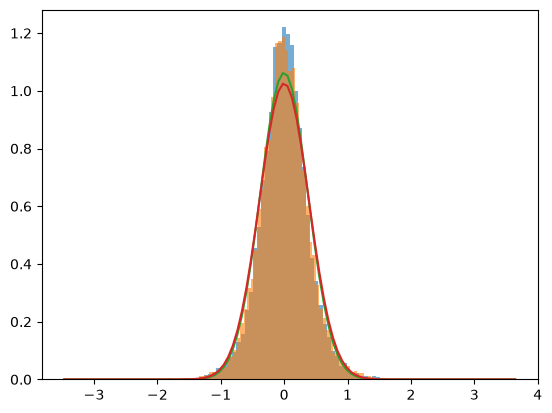

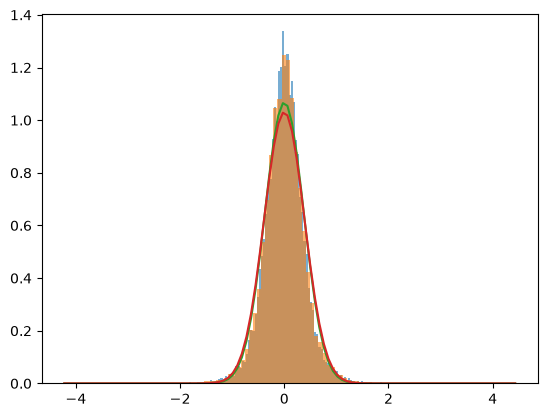

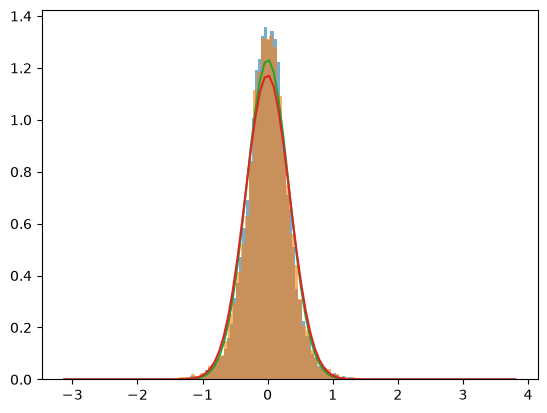

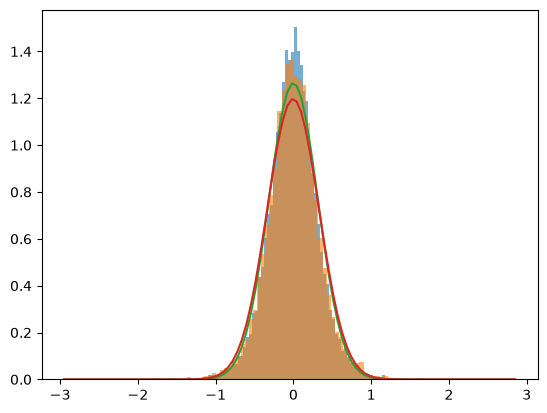

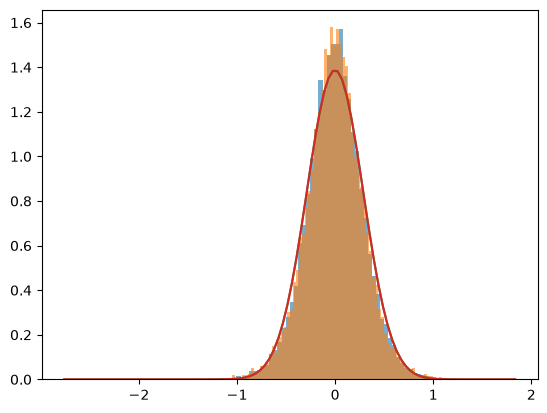

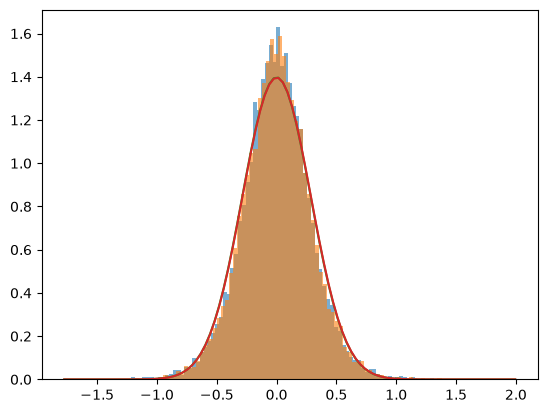

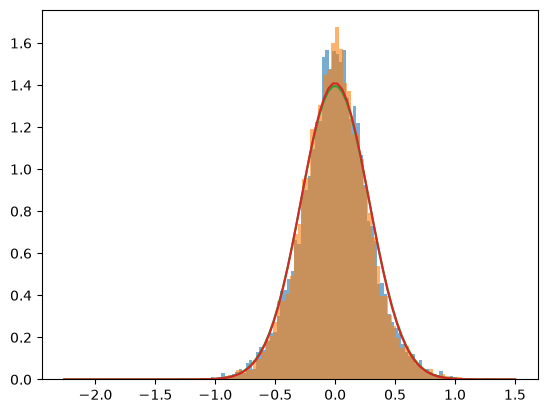

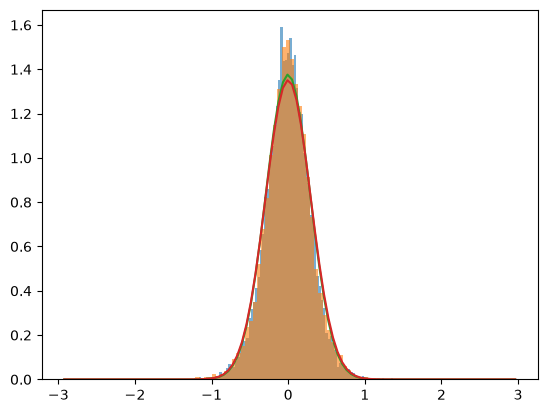

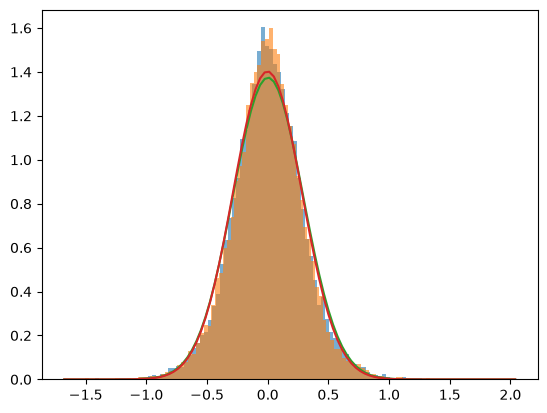

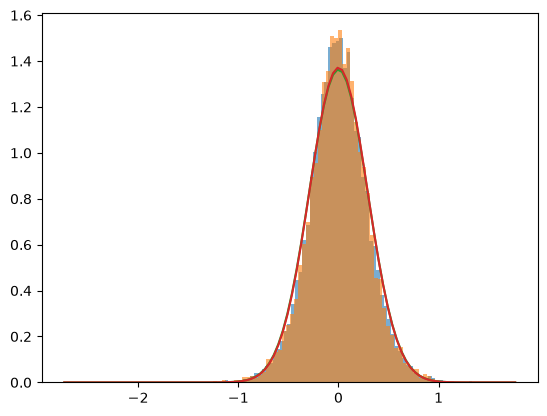

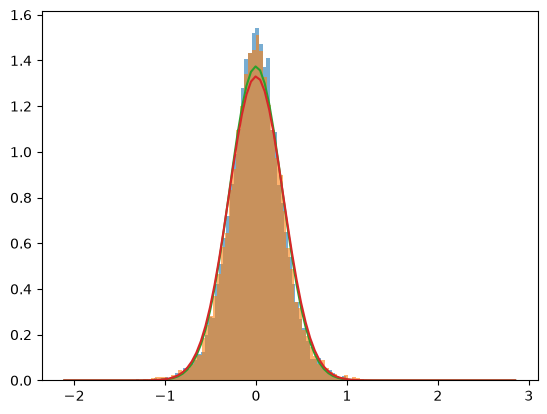

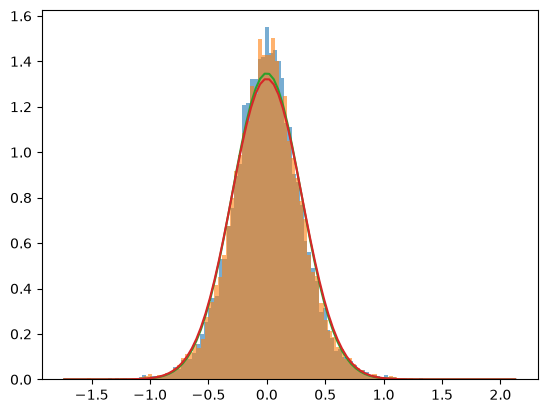

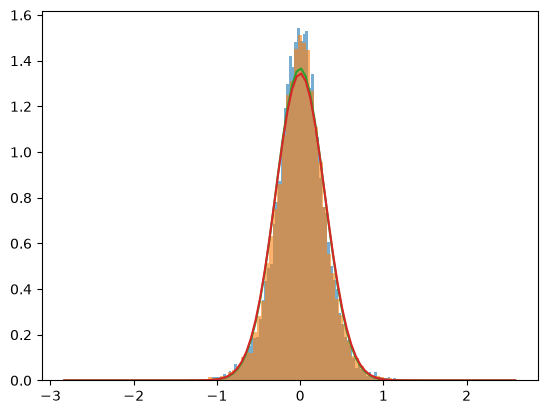

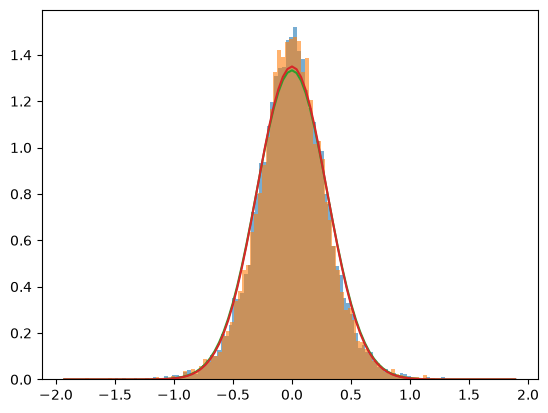

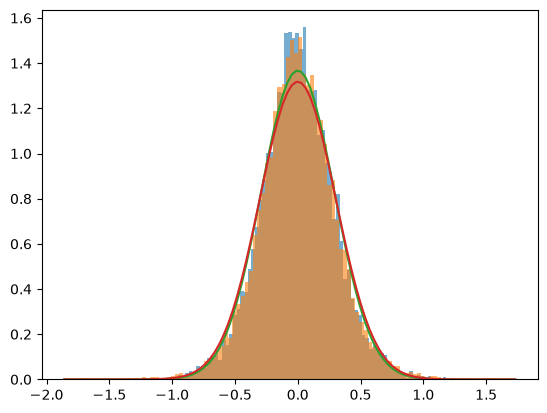

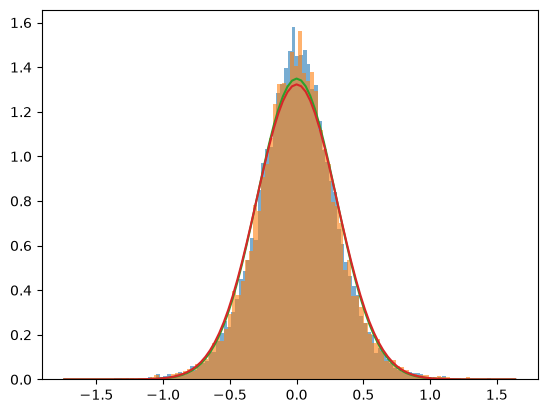

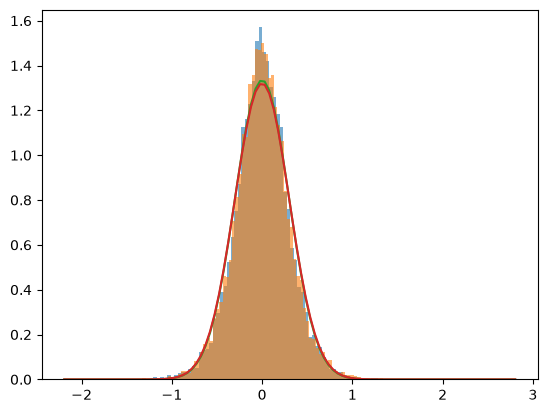

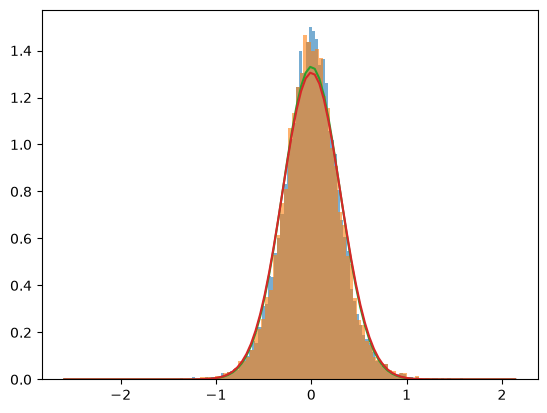

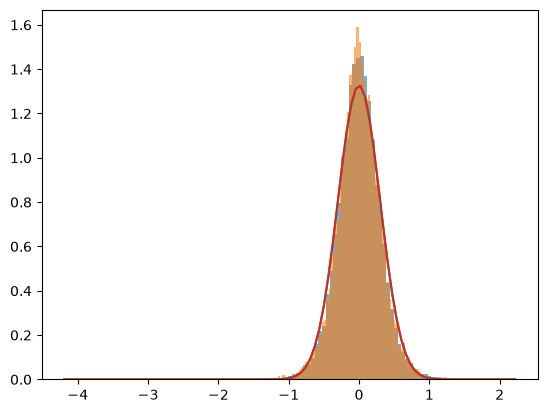

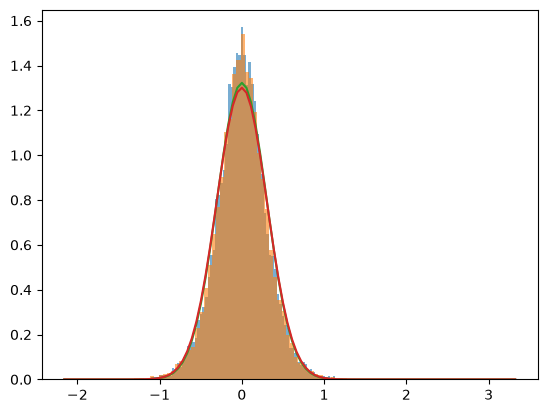

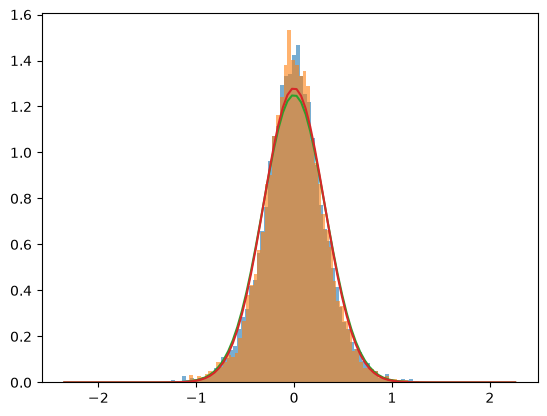

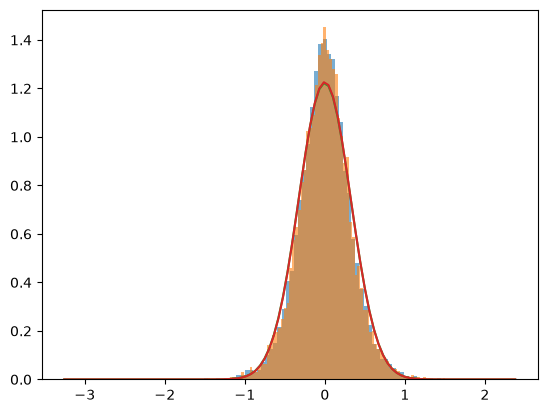

In [4]:
standard_deviations = []
means = []
print(len(XGBoost_distances_all_data))


for element in XGBoost_distances_all_data:

    delta_x = element[:, :, 0]
    delta_x = delta_x[delta_x != 0]

    delta_y = element[:, :, 1]
    delta_y = delta_y[delta_y != 0]

    meanx, stdx = norm.fit(delta_x)
    meany, stdy = norm.fit(delta_y)

    standard_deviations.append([stdx, stdy])
    means.append([meanx, meany])

    plt.hist(delta_x,bins=100,alpha=0.6,label='delta X',density=True)
    plt.hist(delta_y,bins=100,alpha=0.6,label='delta Y',density=True)

    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)

    xy = norm.pdf(x, meanx, stdx)
    yy = norm.pdf(x, meany, stdy)

    plt.plot(x, xy)
    plt.plot(x, yy)

    plt.show()

In [5]:
# Standard deviations
std_x = np.std(delta_x)
std_y = np.std(delta_y)

print("Standard Deviation X (mm):", std_x)
print("Standard Deviation Y (mm):", std_y)

Standard Deviation X (mm): 0.32633439004603476
Standard Deviation Y (mm): 0.3253406916207846


In [6]:
XGBoost_distances_all_data_np = np.array(XGBoost_distances_all_data)
print(XGBoost_distances_all_data_np.shape)
np.savetxt('XGBoost_distances_delta_cut.csv', XGBoost_distances_all_data_np.reshape(XGBoost_distances_all_data_np.shape[0], -1))

(35, 301, 301, 2)
